# Ambiguous Union (p. 13, eqs 24–28)

The expression $e_{\mathrm{ex}\cup} = \langle aa\rangle^*_{\leq 1}\langle a\rangle_{\leq 1} \cup \langle a\rangle_{\leq 1}\langle aa\rangle^*_{\leq 1}$.

Volume identity $V^{e_\cup} = V^\mathcal{M} - V^{e_\cap}$; rejection rate plotted over the support interval.

In [2]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import sys, os, time, random
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.size": 11,
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.serif": [],
    "font.weight": "normal",
    "figure.dpi": 110,
})

def _find_repo_root():
    try:
        d = os.path.abspath(os.getcwd())
    except (FileNotFoundError, OSError):
        d = '/workspace'
    while True:
        if os.path.isfile(os.path.join(d, "parse", "quickparse.py")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            raise RuntimeError("repo root not found")
        d = parent

REPO = _find_repo_root()
for p in [REPO, os.path.join(REPO, "experiments", "paper_experiments")]:
    if p not in sys.path:
        sys.path.insert(0, p)

from parse.quickparse import quickparse
from sample.sample import sample
from volume.slice_volume import slice_volume

random.seed(42); np.random.seed(42)

RESULTS = os.path.join(REPO, "experiments", "paper_experiments",
                       "12_page13_casestudy", "results")
os.makedirs(RESULTS, exist_ok=True)

# Quick smoke test
_phi = quickparse("<a>_[0,1] *", string=True)
_w   = sample(_phi, 3)
print("VolTRE OK:", _w)


VolTRE OK: (0.389, a),(0.816, a),(0.485, a)


### The expression

The paper considers the union

$$e_{\mathrm{ex}\cup}
  = \underbrace{\langle aa\rangle^*_{\leq 1}\langle a\rangle_{\leq 1}}_{e_{\mathrm{left}}}
  \cup
  \underbrace{\langle a\rangle_{\leq 1}\langle aa\rangle^*_{\leq 1}}_{e_{\mathrm{right}}}$$

- $e_{\mathrm{left}}$: zero or more $aa$-pairs (each within $\leq 1$), then one final $a$ (within $\leq 1$).
  Word lengths are odd: $n = 1, 3, 5, \ldots$
- $e_{\mathrm{right}}$: one $a$ (within $\leq 1$), then zero or more $aa$-pairs (each within $\leq 1$).
  Same word lengths, symmetric structure.

The two branches overlap: any word $w$ with $n \geq 3$ events that fits both timing
constraints belongs to the **intersection** $e_{\mathrm{ex}\cap} = e_{\mathrm{left}} \cap e_{\mathrm{right}}$.
This makes the union **ambiguous** — such a word has two distinct parse trees.

### How VolTRE computes volumes for a union

`slice_volume` on a union **sums the branch volumes** without doing
inclusion-exclusion.  Call this the *multiset volume*:

$$V_n^{\mathcal{M}}(T) := V_n^{e_{\mathrm{left}}}(T) + V_n^{e_{\mathrm{right}}}(T) = 2\,V_n^{e_{\mathrm{left}}}(T)$$

(the two branches are symmetric, so both volumes are equal).
Words in the intersection are **counted twice** in $V^{\mathcal{M}}$.

The true set-theoretic union volume follows by inclusion-exclusion (paper eq 24/25):

$$\boxed{V_n^{e_{\mathrm{ex}\cup}}(T)
  = V_n^{\mathcal{M}}(T) - V_n^{e_{\mathrm{ex}\cap}}(T)}$$

### How VolTRE samples from an ambiguous union (smart rejection)

VolTRE's sampler (`sample.py`, `smart_sampling`) draws from $V^{\mathcal{M}}$
uniformly, then corrects for the overcounting:

1. Draw a timed word $w$ uniformly from the *disambiguated* expression
   (each branch is labelled so duplicates are distinguishable).
2. Count $N(w)$ = number of parse trees of $w$ in the original expression.
   For $w \notin e_{\mathrm{ex}\cap}$: $N(w) = 1$.  For $w \in e_{\mathrm{ex}\cap}$: $N(w) = 2$.
3. Accept with probability $1/N(w)$, else reject and restart.

This turns a uniform draw from $V^{\mathcal{M}}$ into a uniform draw from
$V^{e_{\mathrm{ex}\cup}}$ (the *true* uniform distribution, not the multiset one).

### Measuring $V^{e_{\mathrm{ex}\cap}}$ via the rejection rate

`sample(..., feedback=True)` returns a `Feedback` namedtuple with field
`smart_rej` = number of restarts before acceptance for that one sample.

Over $K$ successful samples with a total of $R$ restarts,
the empirical rejection rate is $\hat p_{\mathrm{rej}} = R / (K + R)$.

Why does this equal $V^{e_{\mathrm{ex}\cap}} / V^{\mathcal{M}}$?
Because intersection words appear in **two** branches in the disambiguated
expression, so they are drawn with probability $2\,V^{e_{\mathrm{ex}\cap}} / V^{\mathcal{M}}$,
and each such draw is rejected with probability $1/2$ (step 3).
Hence $P(\text{reject a draw}) = V^{e_{\mathrm{ex}\cap}} / V^{\mathcal{M}}$, and so

$$\hat V_n^{e_{\mathrm{ex}\cap}}(T) = \hat p_{\mathrm{rej}}(T) \cdot V_n^{\mathcal{M}}(T)$$

The three plots below verify this identity and show how $p_{\mathrm{rej}}$ varies with $T$.


In [10]:
# Paper expressions (eq 24-28)
# e_left  = <aa>*_<=1 . <a>_<=1   (zero-or-more aa-pairs each <=1, then one a <=1)
# e_right = <a>_<=1  . <aa>*_<=1  (one a <=1, then zero-or-more aa-pairs each <=1)
# e_union = e_left + e_right        (union; word lengths must be odd: n=1,3,5,...)
# e_inter = e_left & e_right        (intersection; non-trivial for n>=3)
phi_left  = quickparse("<a . a>_[0,1] * . <a>_[0,1]",  string=True)
phi_right = quickparse("<a>_[0,1] . <a . a>_[0,1] *",  string=True)
phi_union = quickparse(
    "(<a . a>_[0,1] * . <a>_[0,1]) + (<a>_[0,1] . <a . a>_[0,1] *)",
    string=True)
phi_inter = quickparse(
    "(<a . a>_[0,1] * . <a>_[0,1]) & (<a>_[0,1] . <a . a>_[0,1] *)",
    string=True)

# Sanity: sample a few words from each expression
for name, phi in [("e_left", phi_left), ("e_right", phi_right),
                  ("e_union", phi_union), ("e_inter", phi_inter)]:
    w = sample(phi, 3, T=0.8)
    print(f"{name:8s}  n=3 T=0.8 :  {w}")


e_left    n=3 T=0.8 :  (0.388, a),(0.318, a),(0.094, a)
e_right   n=3 T=0.8 :  (0.561, a),(0.112, a),(0.127, a)
e_union   n=3 T=0.8 :  (0.241, a),(0.067, a),(0.491, a)
e_inter   n=3 T=0.8 :  (0.537, a),(0.077, a),(0.186, a)


In [11]:
# Sanity: show rejection feedback for a handful of union samples
# smart_rej > 0 means the word was in the intersection and took multiple draws
print("phi_union samples (n=3, T=0.8) with smart_rej count:")
for _ in range(8):
    w, fb = sample(phi_union, 3, T=0.8, feedback=True)
    marker = "  <-- intersection word (rejected before)" if fb.smart_rej > 0 else ""
    print(f"  {w}  [smart_rej={fb.smart_rej}]{marker}")


phi_union samples (n=3, T=0.8) with smart_rej count:
  (0.037, a),(0.358, a),(0.405, a)  [smart_rej=0]
  (0.053, a),(0.179, a),(0.568, a)  [smart_rej=1]  <-- intersection word (rejected before)
  (0.060, a),(0.717, a),(0.022, a)  [smart_rej=0]
  (0.210, a),(0.425, a),(0.165, a)  [smart_rej=0]
  (0.160, a),(0.055, a),(0.585, a)  [smart_rej=1]  <-- intersection word (rejected before)
  (0.042, a),(0.091, a),(0.668, a)  [smart_rej=2]  <-- intersection word (rejected before)
  (0.008, a),(0.707, a),(0.085, a)  [smart_rej=0]
  (0.056, a),(0.737, a),(0.007, a)  [smart_rej=0]


### Computing $V^{\mathcal{M}}$ and estimating $V^{e_{\mathrm{ex}\cap}}$

For each $(n, T)$ we:
1. Compute $V_n^{\mathcal{M}}(T)$ exactly via `slice_volume(phi_union, n)` evaluated at $T$.
2. Collect $K = 30$ samples from `phi_union` with `feedback=True`, summing up `smart_rej` counts.
3. Estimate $\hat p_{\mathrm{rej}}(T) = R / (K + R)$ and hence
   $\hat V^{e_{\mathrm{ex}\cap}}(T) = \hat p_{\mathrm{rej}}(T) \cdot V^{\mathcal{M}}(T)$.

We run this for $n = 3, 5, 7$ (odd, the only supported lengths) over $T \in (0, 2)$.


In [12]:
# T_max for e_left = (<aa>_[0,1]* . <a>_[0,1]): (n+1)/2 for odd n
T_MAX  = {3: 2.0, 5: 3.0, 7: 4.0}
N_SAMPLE = 30

partB = {}
for n in [3, 5, 7]:
    T_hi   = T_MAX[n]
    T_grid = np.linspace(0.05, T_hi - 0.05, 40)
    v_M_arr, v_inter_arr, p_rej_arr, T_ok = [], [], [], []
    print(f"n={n}  T in (0, {T_hi}) ...", end="", flush=True)

    vu_poly = slice_volume(phi_union, n)

    for T_np in T_grid:
        T = float(T_np)
        try:
            vm = float(vu_poly(T))
            if vm <= 1e-15:
                continue

            smart_rej_counts = [
                sample(phi_union, n, T=T, feedback=True)[1].smart_rej
                for _ in range(N_SAMPLE)
            ]
            R = sum(smart_rej_counts)
            K = N_SAMPLE
            p_rej   = R / (K + R)
            v_inter = vm * p_rej

            v_M_arr.append(vm); v_inter_arr.append(v_inter)
            p_rej_arr.append(p_rej); T_ok.append(T)
        except Exception:
            pass

    partB[n] = dict(T=T_ok, v_M=v_M_arr, v_inter=v_inter_arr, p_rej=p_rej_arr)
    print(f" {len(T_ok)} points OK")

print("Done.")


n=3  T in (0, 2.0) ... 40 points OK
n=5  T in (0, 3.0) ... 40 points OK
n=7  T in (0, 4.0) ... 40 points OK
Done.


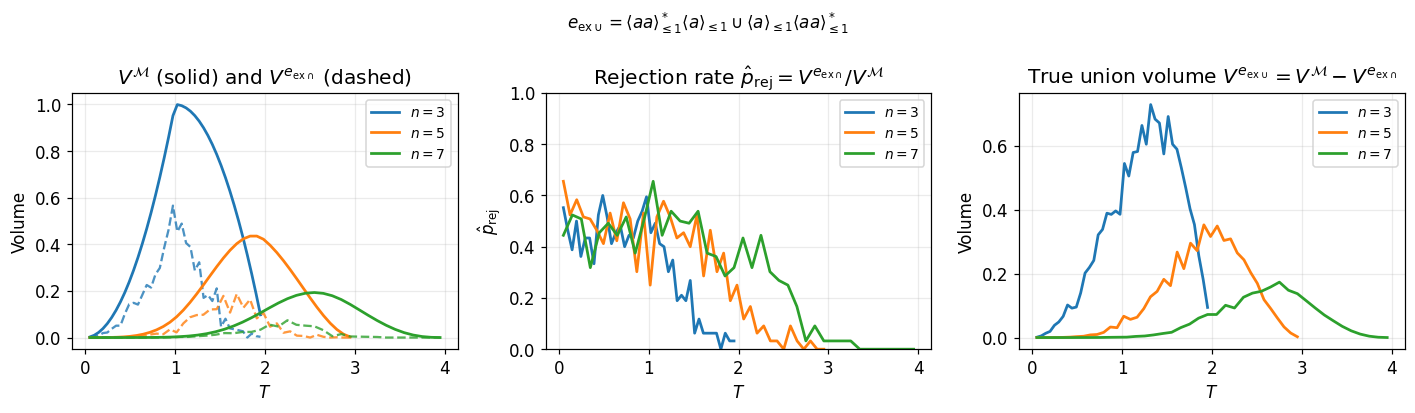

Saved 12_partB_volumes.pdf


In [13]:
colors_n = {3: "#1f77b4", 5: "#ff7f0e", 7: "#2ca02c"}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

ax = axes[0]
for n, d in partB.items():
    c = colors_n[n]
    ax.plot(d["T"], d["v_M"],     color=c, lw=1.8, label=f"$n={n}$")
    ax.plot(d["T"], d["v_inter"], color=c, lw=1.5, linestyle="--", alpha=0.8)
ax.set_xlabel("$T$")
ax.set_ylabel("Volume")
ax.set_title(r"$V^{\mathcal{M}}$ (solid) and $V^{e_{\mathrm{ex}\cap}}$ (dashed)")
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

ax = axes[1]
for n, d in partB.items():
    v_M = np.array(d["v_M"]); v_i = np.array(d["v_inter"])
    safe = v_M > 1e-15
    ax.plot(np.array(d["T"])[safe], v_i[safe] / v_M[safe],
            color=colors_n[n], lw=1.8, label=f"$n={n}$")
ax.set_xlabel("$T$")
ax.set_ylabel(r"$\hat p_{\mathrm{rej}}$")
ax.set_title(r"Rejection rate $\hat p_{\mathrm{rej}} = V^{e_{\mathrm{ex}\cap}} / V^{\mathcal{M}}$")
ax.legend(fontsize=9); ax.set_ylim(0, 1); ax.grid(True, alpha=0.25)

ax = axes[2]
for n, d in partB.items():
    v_M = np.array(d["v_M"]); v_i = np.array(d["v_inter"])
    v_true = v_M - v_i
    ax.plot(d["T"], v_true, color=colors_n[n], lw=1.8, label=f"$n={n}$")
ax.set_xlabel("$T$")
ax.set_ylabel("Volume")
ax.set_title(r"True union volume $V^{e_{\mathrm{ex}\cup}} = V^{\mathcal{M}} - V^{e_{\mathrm{ex}\cap}}$")
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

fig.suptitle(
    r"$e_{\mathrm{ex}\cup}"
    r"= \langle aa\rangle^*_{\leq 1}\langle a\rangle_{\leq 1}"
    r"\cup \langle a\rangle_{\leq 1}\langle aa\rangle^*_{\leq 1}$",
    fontsize=11)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, "12_partB_volumes.pdf"), bbox_inches="tight")
plt.show()
print("Saved 12_partB_volumes.pdf")


### Reading the plots

**Left panel — $V^{\mathcal{M}}$ and $V^{e_{\mathrm{ex}\cap}}$:**
- $V^{\mathcal{M}}$ (solid) is what `slice_volume` returns for `phi_union`.
  It equals $2\,V^{e_{\mathrm{left}}}$ and grows with $T$ (more time = more
  timed words), saturating once $T$ exceeds the tightest constraint.
- $V^{e_{\mathrm{ex}\cap}}$ (dashed, estimated) is the intersection volume —
  words matched by *both* branches.  It peaks around $T \approx 1$ where both
  constraints are roughly equally binding, then shrinks as $T \to 2$.
- Larger $n$ means higher-degree polynomials and smaller absolute volumes,
  but the same qualitative shape.

**Middle panel — rejection rate $\hat p_{\mathrm{rej}}$:**
- Near $T = 1$ roughly half of all draws are rejected, so sampling throughput
  is halved compared to an unambiguous expression.
- As $T \to 0$ or $T \to 2$ the intersection becomes small relative to
  $V^{\mathcal{M}}$, and the rejection rate drops.

**Right panel — true union volume:**
- $V^{e_{\mathrm{ex}\cup}} = V^{\mathcal{M}} - V^{e_{\mathrm{ex}\cap}}$
  is the actual set-theoretic volume of the union (paper eq 25).
- It is always $\leq V^{\mathcal{M}}$; the gap equals the intersection volume
  that was double-counted.

### Connection to Nicolas's rejection-rate experiment

Nicolas's request/grant expression for $k$ request types will also produce
**two distinct sources** of rejection:

| Source | Mechanism | Counter |
|---|---|---|
| Ambiguity | Multiple parse trees for the same word | `smart_rej` |
| Intersection (top-level `&`) | Match fails in second child | `intersect_rej` |

Part B isolates the first source.  For the full $e''_\mathcal{T}$ with $k \geq 2$,
both counters will be non-zero; measuring them separately (as the `Feedback` namedtuple
already supports) is the key step in Nicolas's bar-chart experiment.


---
## Summary

| Expression | What we showed |
|---|---|
| $e_{\mathrm{ex}\cup}$ | $V^\mathcal{M} - V^{e_\cap}$ identity; rejection rate $\approx 30$–50% near $T=1$ |

**Nicolas's experiment**: measure `smart_rej` (ambiguity) and `intersect_rej`
(top-level `&`) separately for $e''_\mathcal{T}$ at $k = 5, 10, 15$;
compare VolTRE vs TA sampling times.